# RQ3 - PGD false positive on the drift detector

Can bounded feature perturbation push known-class flows past the drift threshold, and force a concept-discovery event? 

Phases: white-box, surrogate transfer, end-to-end, accumulator-targeted.

In [1]:
import os, sys, copy
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../..'))
from src.experiments.contrastive_ncm import (
    load_cicids2017,
    prepare_temporal_split,
    BaseLearnerMLP,
    StaticDAdaptiveM,
    run_stream,
    initial_training,
    apply_paper_style,
    save_fig,
    save_latex,
    DAY_NAMES_DEFAULT,
)
from src.detectors.contrastive_ncm import ContrastiveNCMDetector
from src.experiments.contrastive_ncm.pgd_attack import pgd_drift_attack, flag_rate

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_float32_matmul_precision('high')

DATA_DIR = os.path.abspath('../../data/CICIDS2017_Engelen')
FIGURE_DIR = os.path.abspath('./figures')
TABLE_DIR = os.path.abspath('./tables')

NOVEL_CLASSES = ['DoS', 'PortScan']
M_HIDDEN = (256, 128, 64)
CONCEPT_BATCH = 256
BATCH_SIZE = 1000

# PGD configuration
PGD_NORM = 'linf'
PGD_STEPS = 50
EPS_GRID = [0.0, 0.1, 0.25, 0.5, 1.0, 2.0]  # L-inf budget, standardised-feature units
ATTACK_POOL_N = 2000
SURROGATE_SEED = RANDOM_SEED + 999

apply_paper_style()
print('Device:', DEVICE)


# --- Output verbosity: set PROGRESS=False for short, clean saved notebooks ---
from src.experiments.contrastive_ncm import set_progress, set_stream_verbose
PROGRESS = False  # True = live tqdm bars + per-fire stream diagnostics
set_progress(PROGRESS)
set_stream_verbose(PROGRESS)

Device: cuda


/home/azureuser/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load and split

In [2]:
print('Loading CICIDS2017...')
data = load_cicids2017(DATA_DIR)
print(f'  Rows: {len(data.X):,}  Features: {data.input_dim}')
split = prepare_temporal_split(
    data,
    novel_classes=NOVEL_CLASSES,
    per_class_metric_names=NOVEL_CLASSES,
    random_seed=RANDOM_SEED,
)
DAY_NAMES = DAY_NAMES_DEFAULT
print(f'  Known classes: {split.n_known}   Stream: {len(split.X_stream):,}')


Loading CICIDS2017...


  Rows: 2,100,814  Features: 77


  Known classes: 7   Stream: 763,401


## Victim detector (disjoint 60% partition)

Design B: the known-class training pool `X_tr` is split into two disjoint, stratified parts. The victim trains on 60%; the held-out 40% is reserved for the grey-box surrogate(s), so victim and surrogate share no training flows.

In [3]:
from sklearn.model_selection import train_test_split


# Design B: disjoint victim / surrogate partition of the known-class training pool.
# The victim trains on a stratified 75% of X_tr; the held-out 25% (X_sur) is reserved
# for training the grey-box surrogate(s) in Phase 2, so victim and surrogate share NO
# training flows. The attack pool (Phase 0) is drawn from the eval split and is disjoint
# from both. Stratifying on the multiclass label keeps every known class present on both
# sides (the rare classes survive the split, avoiding a starved surrogate).
VIC_FRACTION = 0.75
(X_vic, X_sur,
 yvic_mc, ysur_mc,
 yvic_bin, ysur_bin) = train_test_split(
    split.X_tr, split.y_tr_mc, split.y_tr_bin,
    train_size=VIC_FRACTION, random_state=RANDOM_SEED, stratify=split.y_tr_mc,
)
print(f'Victim pool: {len(X_vic):,}   surrogate pool (disjoint): {len(X_sur):,}')

print('Victim initial training (DD 300ep + M + calibration) on the 75% partition...')
victim_init = initial_training(
    X_tr=X_vic,
    y_tr_mc=yvic_mc,
    y_tr_bin=yvic_bin,
    n_known=split.n_known,
    input_dim=data.input_dim,
    device=DEVICE,
    random_seed=RANDOM_SEED,
)
print(
    f'  drift_threshold = {victim_init.drift_threshold:.4f}   concept_threshold T = {victim_init.concept_threshold:.4f}'
)


def build_detector(itr):
    # Reconstruct a ContrastiveNCMDetector (victim or surrogate) from an InitialTrainingResult.
    det = ContrastiveNCMDetector(
        input_dim=data.input_dim,
        hidden_dim=64,
        latent_dim=32,
        temperature=0.1,
        device=DEVICE,
    )
    det.autoencoder.load_state_dict(copy.deepcopy(itr.dd_init_ae))
    det.ncm = copy.deepcopy(itr.dd_init_ncm)
    det.drift_threshold = itr.drift_threshold
    det.concept_threshold = itr.concept_threshold
    det.num_classes = split.n_known
    det._reset_drift_buffer()
    return det


victim_det = build_detector(victim_init)
print('Victim detector rebuilt.')

Victim pool: 995,559   surrogate pool (disjoint): 331,854
Victim initial training (DD 300ep + M + calibration) on the 75% partition...


    [Contrastive 20/300] loss=0.1657


    [Contrastive 40/300] loss=0.0868


    [Contrastive 60/300] loss=0.0605


    [Contrastive 80/300] loss=0.0442


...

    [M 40/100] loss=0.0005


    [M 60/100] loss=0.0002


    [M 80/100] loss=0.0002


    [M 100/100] loss=0.0003


  drift_threshold = 1.3226   concept_threshold T = 39.2859
Victim detector rebuilt.


## Attack pool and clean baseline

In [4]:
known_eval = split.X_eval[~split.novel_mask_eval]
rng = np.random.default_rng(RANDOM_SEED + 3)
idx = rng.choice(len(known_eval), min(ATTACK_POOL_N, len(known_eval)), replace=False)
X_pool = known_eval[idx].cpu().numpy().astype(np.float32)

# Per-feature valid range (keep perturbed flows plausible) from known training data.
x_min = split.X_tr.min(axis=0)
x_max = split.X_tr.max(axis=0)

clean_flag = flag_rate(
    victim_det.autoencoder, victim_det.ncm, victim_det.drift_threshold, X_pool, device=DEVICE
)
print(f'Attack pool: {len(X_pool):,} known-class samples')
print(f'Clean drift-flag rate on victim (no attack): {clean_flag:.3f}')

Attack pool: 2,000 known-class samples
Clean drift-flag rate on victim (no attack): 0.103


## Phase 1 — white-box PGD

In [5]:
print('Phase 1 - white-box PGD on the victim detector')
wb_flag, wb_adv = {}, {}
for eps in EPS_GRID:
    if eps == 0.0:
        wb_flag[eps] = clean_flag
        continue
    Xadv = pgd_drift_attack(
        victim_det.autoencoder,
        victim_det.ncm,
        X_pool,
        eps=eps,
        steps=PGD_STEPS,
        norm=PGD_NORM,
        x_min=x_min,
        x_max=x_max,
        device=DEVICE,
    )
    wb_adv[eps] = Xadv
    wb_flag[eps] = flag_rate(
        victim_det.autoencoder, victim_det.ncm, victim_det.drift_threshold, Xadv, device=DEVICE
    )
    print(f'  eps={eps:<4}  white-box flag rate = {wb_flag[eps]:.3f}')

Phase 1 - white-box PGD on the victim detector


  eps=0.1   white-box flag rate = 0.286
  eps=0.25  white-box flag rate = 0.858
  eps=0.5   white-box flag rate = 0.998


  eps=1.0   white-box flag rate = 0.997
  eps=2.0   white-box flag rate = 1.000


## Phase 2 — grey-box surrogate transfer (disjoint data)

The surrogate shares the victim's architecture and hyperparameters but is trained on the disjoint 40% partition `X_sur` — no training flows are shared with the victim. We craft the attack against the surrogate and transfer it to the victim, averaging over three surrogate seeds (init + internal calibration split) to report mean ± std transfer.

In [6]:
print('Phase 2 - training disjoint surrogate detectors (no training flows shared with the victim)...')

SURR_SEEDS = [RANDOM_SEED + 999, RANDOM_SEED + 1000, RANDOM_SEED + 1001]


def train_surrogate(seed):
    itr = initial_training(
        X_tr=X_sur,
        y_tr_mc=ysur_mc,
        y_tr_bin=ysur_bin,
        n_known=split.n_known,
        input_dim=data.input_dim,
        device=DEVICE,
        random_seed=seed,
    )
    return build_detector(itr)


disjoint_surrogates = []
for s in SURR_SEEDS:
    surrogate_det = train_surrogate(s)
    disjoint_surrogates.append(surrogate_det)
    print(f'  [seed {s}] surrogate drift_threshold = {surrogate_det.drift_threshold:.4f}')

print('Crafting per-sample PGD on each surrogate, transferring to the victim...')
surr_flag, surr_flag_std, surr_adv = {}, {}, {}
for eps in EPS_GRID:
    if eps == 0.0:
        surr_flag[eps] = clean_flag
        surr_flag_std[eps] = 0.0
        continue
    rates = []
    for k, surrogate_det in enumerate(disjoint_surrogates):
        Xadv = pgd_drift_attack(
            surrogate_det.autoencoder,
            surrogate_det.ncm,
            X_pool,
            eps=eps,
            steps=PGD_STEPS,
            norm=PGD_NORM,
            x_min=x_min,
            x_max=x_max,
            device=DEVICE,
        )
        if k == 0:
            surr_adv[eps] = Xadv  # keep one craft for the end-to-end cell
        rates.append(
            flag_rate(victim_det.autoencoder, victim_det.ncm, victim_det.drift_threshold, Xadv, device=DEVICE)
        )
    surr_flag[eps] = float(np.mean(rates))
    surr_flag_std[eps] = float(np.std(rates))
    print(
        f'  eps={eps:<4}  surrogate->victim transfer flag rate = '
        f'{surr_flag[eps]:.3f} +/- {surr_flag_std[eps]:.3f}'
    )

Phase 2 - training disjoint surrogate detectors (no training flows shared with the victim)...


    [Contrastive 20/300] loss=0.4572


    [Contrastive 40/300] loss=0.2791


    [Contrastive 60/300] loss=0.1808


    [Contrastive 80/300] loss=0.1243


...

  eps=0.1   surrogate->victim transfer flag rate = 0.167 +/- 0.007


  eps=0.25  surrogate->victim transfer flag rate = 0.244 +/- 0.037


  eps=0.5   surrogate->victim transfer flag rate = 0.322 +/- 0.061


  eps=1.0   surrogate->victim transfer flag rate = 0.418 +/- 0.078


  eps=2.0   surrogate->victim transfer flag rate = 0.599 +/- 0.134


## Results

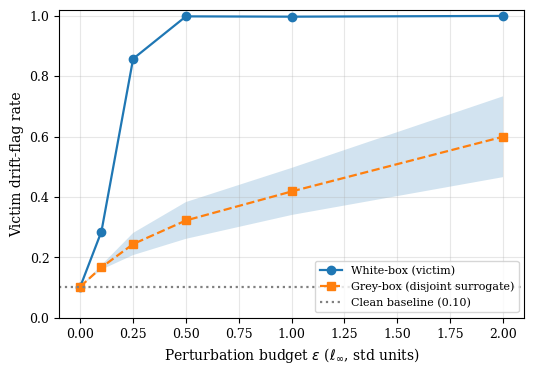

,White-box flag,Grey-box flag (mean),Grey-box flag (std)
eps,,,
0.00,0.103,0.103,0.000
0.10,0.286,0.167,0.007
0.25,0.858,0.244,0.037
0.50,0.998,0.322,0.061
1.00,0.997,0.418,0.078
2.00,1.000,0.599,0.134


In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
xs = EPS_GRID
ax.plot(xs, [wb_flag[e] for e in xs], 'o-', label='White-box (victim)')
gb = np.array([surr_flag[e] for e in xs])
gb_sd = np.array([surr_flag_std[e] for e in xs])
ax.plot(xs, gb, 's--', label='Grey-box (disjoint surrogate)')
ax.fill_between(xs, gb - gb_sd, gb + gb_sd, alpha=0.2)
ax.axhline(clean_flag, color='grey', ls=':', label=f'Clean baseline ({clean_flag:.2f})')
ax.set_xlabel(r'Perturbation budget $\epsilon$ ($\ell_\infty$, std units)')
ax.set_ylabel('Victim drift-flag rate')
ax.set_ylim(0, 1.02)
ax.legend()
save_fig(fig, 'rq3_pgd_false_positive', FIGURE_DIR)
plt.show()

pgd_df = pd.DataFrame(
    [
        {
            'eps': e,
            'White-box flag': f'{wb_flag[e]:.3f}',
            'Grey-box flag (mean)': f'{surr_flag[e]:.3f}',
            'Grey-box flag (std)': f'{surr_flag_std[e]:.3f}',
        }
        for e in EPS_GRID
    ]
).set_index('eps')
display(pgd_df)
save_latex(
    pgd_df,
    'rq3_pgd_false_positive.tex',
    TABLE_DIR,
    caption='PGD false-positive attack on the Contrastive-NCM drift detector: fraction of '
    'perturbed known-class samples the victim flags as drifted, versus the L-infinity '
    'perturbation budget eps. White-box perturbs the victim directly; grey-box perturbs a '
    'disjoint surrogate -- trained on a held-out 40 percent of the known-class pool, with no '
    'training flows shared with the victim -- and transfers to the victim (mean and std over '
    'three surrogate seeds).',
    label='tab:rq3-pgd-false-positive',
)

## Phase 3 - end-to-end

In [8]:
# Pre-drift window: batches before the first genuine novel class (DoS).
novel_stream_mask = np.isin(split.y_stream, split.novel_ids)
PRE_DRIFT_DAY = int(split.d_stream[novel_stream_mask].min())
batch_days = split.d_stream[::BATCH_SIZE]
cutoff_batch = int(np.argmax(batch_days >= PRE_DRIFT_DAY))
print(f'Pre-drift window = batches [0, {cutoff_batch}) (days < {PRE_DRIFT_DAY}).')

ATTACK_EPS = next((e for e in EPS_GRID if e > 0 and wb_flag[e] >= 0.9), EPS_GRID[-1])
print(f'End-to-end attack eps = {ATTACK_EPS}')


def build_static_system():
    victim_dd = build_detector(victim_init)  # victim detector (encoder frozen)
    ml = BaseLearnerMLP(data.input_dim, M_HIDDEN).to(DEVICE)
    ml.load_state_dict(copy.deepcopy(victim_init.m_init_state))
    return StaticDAdaptiveM(
        detector=victim_dd,
        base_learner=ml,
        X_exemplars=victim_init.X_exemplars,
        y_exemplars=victim_init.y_exemplars,
        m_init_state=victim_init.m_init_state,
        X_eval=split.X_eval,
        y_eval_bin=split.y_eval_bin,
        novel_mask=split.novel_mask_eval,
        per_class_masks=split.per_class_masks,
        concept_batch=CONCEPT_BATCH,
    )


def prewindow_schedule(p, cutoff):
    return lambda b: p if b < cutoff else 0.0


INJECT_RATE = 0.20
pools = {
    'clean known (control)': X_pool,
    'PGD white-box': wb_adv[ATTACK_EPS],
    'PGD surrogate->victim': surr_adv[ATTACK_EPS],
}
e2e_rows = []
for name, pool in pools.items():
    sys_ = build_static_system()
    res = run_stream(
        sys_,
        X_stream=split.X_stream,
        y_stream_bin=split.y_stream_bin,
        d_stream=split.d_stream,
        novel_pool=np.asarray(pool, dtype=np.float32),
        schedule_fn=prewindow_schedule(INJECT_RATE, cutoff_batch),
        min_inject_day=0,
        inject_label=1,
        rng_seed=RANDOM_SEED,
        batch_size=BATCH_SIZE,
    )
    spurious = sum(1 for r in res if r.retrain_fired and r.batch_idx < cutoff_batch)
    fri_f1 = float(np.mean([r.f1 for r in res if r.day_idx == 4]))
    e2e_rows.append(
        {
            'Injected pool': name,
            'Pre-drift fires': spurious,
            'Total M retrains': sys_.retrain_count,
            'Fri F1': f'{fri_f1:.3f}',
        }
    )
    print(f'  {name:24} -> pre-drift fires={spurious}  Fri F1={fri_f1:.3f}')

e2e_df = pd.DataFrame(e2e_rows).set_index('Injected pool')
display(e2e_df)
save_latex(
    e2e_df,
    'rq3_pgd_end_to_end.tex',
    TABLE_DIR,
    caption='End-to-end false positive: injecting PGD-perturbed known-class flows in the '
    'pre-drift window forces a spurious concept-discovery fire on an unchanged '
    'distribution, whereas unperturbed known flows do not. Static-DD coupled system, '
    'injection rate 0.20.',
    label='tab:rq3-pgd-end-to-end',
)

Pre-drift window = batches [0, 172) (days < 2).
End-to-end attack eps = 0.5


    [M 20/100] loss=0.0424


    [M 40/100] loss=0.0363


    [M 60/100] loss=0.0325


    [M 80/100] loss=0.0315


...

    [M 60/100] loss=0.0008


    [M 80/100] loss=0.0007


    [M 100/100] loss=0.0008


  PGD surrogate->victim    -> pre-drift fires=0  Fri F1=0.730


,Pre-drift fires,Total M retrains,Fri F1
Injected pool,,,
clean known (control),0,1,0.970
PGD white-box,0,1,0.748
PGD surrogate->victim,0,1,0.730


## Phase 4 — accumulator-targeted PGD

In [9]:
from src.experiments.contrastive_ncm.pgd_attack import pgd_directional_attack, drift_score

T_concept = victim_det.concept_threshold
print(
    f'concept_threshold T = {T_concept:.2f}   drift_threshold T_drift = {victim_det.drift_threshold:.3f}'
)

u = np.random.default_rng(0).standard_normal(victim_det.ncm.prototypes.shape[1]).astype(np.float32)
u = u / np.linalg.norm(u)


def drifted_embeddings(Xadv):
    Xt = torch.as_tensor(np.asarray(Xadv), dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        h = victim_det.autoencoder.encode(Xt)
        s = drift_score(victim_det.autoencoder, victim_det.ncm, Xt)
    keep = s > victim_det.drift_threshold
    return h[keep].detach(), float(keep.float().mean())


acc_rows = []
for eps in EPS_GRID:
    if eps == 0.0:
        continue
    A = pgd_directional_attack(
        victim_det.autoencoder,
        X_pool,
        u,
        eps=eps,
        sign=+1.0,
        steps=PGD_STEPS,
        norm=PGD_NORM,
        x_min=x_min,
        x_max=x_max,
        device=DEVICE,
    )
    B = pgd_directional_attack(
        victim_det.autoencoder,
        X_pool,
        u,
        eps=eps,
        sign=-1.0,
        steps=PGD_STEPS,
        norm=PGD_NORM,
        x_min=x_min,
        x_max=x_max,
        device=DEVICE,
    )
    zA, flagA = drifted_embeddings(A)
    zB, flagB = drifted_embeddings(B)
    if len(zA) == 0 or len(zB) == 0:
        disp, fired = float('nan'), False
    else:
        disp = float((zB.mean(0) - zA.mean(0)).norm())
        # Faithful check: drive a fresh victim accumulator with the two batches.
        victim_probe = build_detector(victim_init)
        victim_probe.update_with_batch_drifted(zA, allow_fire=True)
        fired = bool(victim_probe.update_with_batch_drifted(zB, allow_fire=True))
    acc_rows.append(
        {
            'eps': eps,
            'flag A': f'{flagA:.2f}',
            'flag B': f'{flagB:.2f}',
            'disp ||mean(B)-mean(A)||': f'{disp:.1f}',
            'T': f'{T_concept:.1f}',
            'forces fire?': fired,
        }
    )
    print(f'  eps={eps:<4} disp={disp:8.1f}  (T={T_concept:.1f})  forces fire={fired}')

acc_df = pd.DataFrame(acc_rows).set_index('eps')
display(acc_df)
save_latex(
    acc_df,
    'rq3_pgd_accumulator.tex',
    TABLE_DIR,
    caption='Accumulator-targeting PGD. Two pools of known-class flows are perturbed in '
    'opposite latent directions; the displacement between consecutive drifted-batch '
    'means is compared to the concept threshold T. A concept-discovery fire is forced '
    'only if the displacement exceeds T.',
    label='tab:rq3-pgd-accumulator',
)

concept_threshold T = 39.29   drift_threshold T_drift = 1.323
  eps=0.1  disp=     5.3  (T=39.3)  forces fire=False
  eps=0.25 disp=     6.8  (T=39.3)  forces fire=False
  eps=0.5  disp=    12.0  (T=39.3)  forces fire=False


  eps=1.0  disp=    14.7  (T=39.3)  forces fire=False
  eps=2.0  disp=    29.5  (T=39.3)  forces fire=False


,flag A,flag B,disp ||mean(B)-mean(A)||,T,forces fire?
eps,,,,,
0.10,0.10,0.11,5.3,39.3,False
0.25,0.12,0.13,6.8,39.3,False
0.50,0.16,0.16,12.0,39.3,False
1.00,0.94,0.50,14.7,39.3,False
2.00,1.00,1.00,29.5,39.3,False


## Phase 4b - accumulator via direct mean-shift

Phase 4 pushed the two pools along a *fixed random* latent direction and reached a displacement just short of $T$. Here we let PGD optimise the direction: it jointly perturbs two pools to directly maximise $\lVert \mathrm{mean}(\phi(X{+}\delta_A)) - \mathrm{mean}(\phi(X{+}\delta_B))\rVert$ --- the encoder's most movable axis --- and re-checks whether the accumulator fires.

In [10]:
from src.experiments.contrastive_ncm.pgd_attack import pgd_meanshift_attack

ms_rows = []
for eps in EPS_GRID:
    if eps == 0.0:
        continue
    A, B = pgd_meanshift_attack(
        victim_det.autoencoder, X_pool, eps=eps, steps=PGD_STEPS,
        norm=PGD_NORM, x_min=x_min, x_max=x_max, device=DEVICE,
    )
    zA, flagA = drifted_embeddings(A)
    zB, flagB = drifted_embeddings(B)
    if len(zA) == 0 or len(zB) == 0:
        disp, fired = float('nan'), False
    else:
        disp = float((zB.mean(0) - zA.mean(0)).norm())
        victim_probe = build_detector(victim_init)
        victim_probe.update_with_batch_drifted(zA, allow_fire=True)
        fired = bool(victim_probe.update_with_batch_drifted(zB, allow_fire=True))
    ms_rows.append({'eps': eps, 'flag A': f'{flagA:.2f}', 'flag B': f'{flagB:.2f}',
                    'disp ||mean(B)-mean(A)||': f'{disp:.1f}', 'T': f'{T_concept:.1f}',
                    'forces fire?': fired})
    print(f'  eps={eps:<4} disp={disp:8.1f}  (T={T_concept:.1f})  forces fire={fired}')

ms_df = pd.DataFrame(ms_rows).set_index('eps')
display(ms_df)
save_latex(ms_df, 'rq3_pgd_meanshift.tex', TABLE_DIR,
           caption='Accumulator attack via direct latent mean-shift: PGD jointly optimises two pools '
                   'to maximise the separation of their drifted-batch means (the quantity the '
                   'concept-discovery accumulator integrates), rather than pushing along a fixed '
                   'random direction. A fire is forced only if the displacement exceeds T.',
           label='tab:rq3-pgd-meanshift')

  eps=0.1  disp=    18.0  (T=39.3)  forces fire=False
  eps=0.25 disp=    26.1  (T=39.3)  forces fire=False


  eps=0.5  disp=    25.6  (T=39.3)  forces fire=False
  eps=1.0  disp=    47.1  (T=39.3)  forces fire=True


  eps=2.0  disp=    91.5  (T=39.3)  forces fire=True


,flag A,flag B,disp ||mean(B)-mean(A)||,T,forces fire?
eps,,,,,
0.10,0.23,0.11,18.0,39.3,False
0.25,0.75,0.17,26.1,39.3,False
0.50,0.77,0.86,25.6,39.3,False
1.00,1.00,1.00,47.1,39.3,True
2.00,1.00,1.00,91.5,39.3,True


### Phase 4c - grey-box mean-shift transfer (disjoint surrogate)

Phase 4b forced a fire *white-box*. Here we test transfer under the grey-box threat model: the two pools are optimised against each **disjoint surrogate** (trained on `X_sur`, no flows shared with the victim), then the displacement of their drifted-batch means is measured on the **victim**. We report the mean and std of the transferred displacement over the three surrogate seeds, and how many of them force a victim fire. If the mean statistic the trigger integrates is shared across independently-trained encoders, the displacement transfers and forcing remains reachable grey-box; if each encoder's most-movable axis is idiosyncratic, it does not.

In [11]:
ms_gb_rows = []
for eps in EPS_GRID:
    if eps == 0.0:
        continue
    disps, fires = [], []
    for surrogate_det in disjoint_surrogates:
        A, B = pgd_meanshift_attack(
            surrogate_det.autoencoder, X_pool, eps=eps, steps=PGD_STEPS,
            norm=PGD_NORM, x_min=x_min, x_max=x_max, device=DEVICE,
        )
        zA, _ = drifted_embeddings(A)  # re-embedded on the victim
        zB, _ = drifted_embeddings(B)
        if len(zA) == 0 or len(zB) == 0:
            disps.append(float('nan'))
            fires.append(False)
            continue
        disps.append(float((zB.mean(0) - zA.mean(0)).norm()))
        victim_probe = build_detector(victim_init)  # fresh victim accumulator
        victim_probe.update_with_batch_drifted(zA, allow_fire=True)
        fires.append(bool(victim_probe.update_with_batch_drifted(zB, allow_fire=True)))
    disp_mean = float(np.nanmean(disps))
    disp_std = float(np.nanstd(disps))
    n_fire = int(sum(fires))
    ms_gb_rows.append({
        'eps': eps,
        'disp mean': f'{disp_mean:.1f}',
        'disp std': f'{disp_std:.1f}',
        'seeds forcing fire': f'{n_fire}/{len(disjoint_surrogates)}',
        'T': f'{T_concept:.1f}',
    })
    print(f'  eps={eps:<4} disp={disp_mean:7.1f} +/- {disp_std:4.1f}  '
          f'fires={n_fire}/{len(disjoint_surrogates)}  (T={T_concept:.1f})')

ms_gb_df = pd.DataFrame(ms_gb_rows).set_index('eps')
display(ms_gb_df)
save_latex(ms_gb_df, 'rq3_pgd_meanshift_greybox.tex', TABLE_DIR,
           caption='Grey-box mean-shift transfer. Two pools are optimised against a disjoint '
                   'surrogate (trained on a held-out 40 percent of the known-class pool, with no flows '
                   'shared with the victim) and the displacement of their drifted-batch means is measured '
                   'on the victim. Reported are the mean and std of the transferred displacement over '
                   'three surrogate seeds and the number of seeds whose transfer forces a victim '
                   'concept-discovery fire. A fire requires the displacement to exceed T (compare the '
                   'white-box mean-shift, tab:rq3-pgd-meanshift).',
           label='tab:rq3-pgd-meanshift-greybox')

  eps=0.1  disp=   11.1 +/-  0.7  fires=0/3  (T=39.3)


  eps=0.25 disp=   18.3 +/-  1.1  fires=0/3  (T=39.3)


  eps=0.5  disp=   20.7 +/-  1.6  fires=0/3  (T=39.3)


  eps=1.0  disp=   33.1 +/-  2.0  fires=0/3  (T=39.3)


  eps=2.0  disp=   65.0 +/-  3.8  fires=3/3  (T=39.3)


,disp mean,disp std,seeds forcing fire,T
eps,,,,
0.10,11.1,0.7,0/3,39.3
0.25,18.3,1.1,0/3,39.3
0.50,20.7,1.6,0/3,39.3
1.00,33.1,2.0,0/3,39.3
2.00,65.0,3.8,3/3,39.3
